In [251]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit


Constantes

In [252]:
R = 248e3 # Ohms
C = 470e-6 # Farads
T = R * C # Time constant
V = 10 # Volts

In [253]:
def Vcap_carga(t, V, T):
    return V * (1 - np.exp(-t / T))

def Vcap_descarga(t, V, T):
    return V * np.exp(-t / T)

Carga

In [254]:
time = np.linspace(0, T, 100) # Time from 0 to 5 time constants

In [255]:
import pandas as pd

df = pd.read_excel('dados_capacitor.xlsx')

df

,T,V
0,0,0.00
1,5,0.26
2,10,0.65
3,15,1.00
4,20,1.32
5,25,1.66
6,30,1.95
7,35,2.26
8,40,2.52
9,45,2.76


In [256]:

t_exp = df["T"] # Tempo em segundos
V_exp = df["V"] # Voltagem medida em volts

# Ajuste do modelo usando curve_fit
popt, pcov = curve_fit(Vcap_carga, t_exp, V_exp, p0=[V, T])

# Parâmetros ajustados
A, B = popt
print(f"Parâmetros ajustados: V0 = {A:.4f}, T = {B:.4f}")
print(f'Equação ajustada: V(t) = {A:.4f} * (1 - exp(-t / {B:.4f}))')

# Calcular o erro padrão dos parâmetros
perr = np.sqrt(np.diag(pcov))
print(f"Erro padrão dos parâmetros: V0 = {perr[0]:.4f}, T = {perr[1]:.4f}")

# Calcular R**2
slope, intercept, r_value, p_value, std_err = linregress(Vcap_carga(t_exp,*popt),V_exp)
print(f"R² = {r_value**2:.4f}")

# Gerar valores ajustados para o gráfico
x_fit = np.linspace(min(t_exp), max(t_exp), 100)
y_fit = Vcap_carga(x_fit, A, B)

# Diferença quando t=tau
dif = Vcap_carga(T, A, B) - Vcap_carga(T, V, T)
print(f'Diferença quando t=tau: {abs(dif):.4f} V')

Parâmetros ajustados: V0 = 7.5479, T = 96.2882
Equação ajustada: V(t) = 7.5479 * (1 - exp(-t / 96.2882))
Erro padrão dos parâmetros: V0 = 0.0270, T = 0.7981
R² = 0.9997
Diferença quando t=tau: 1.0228 V


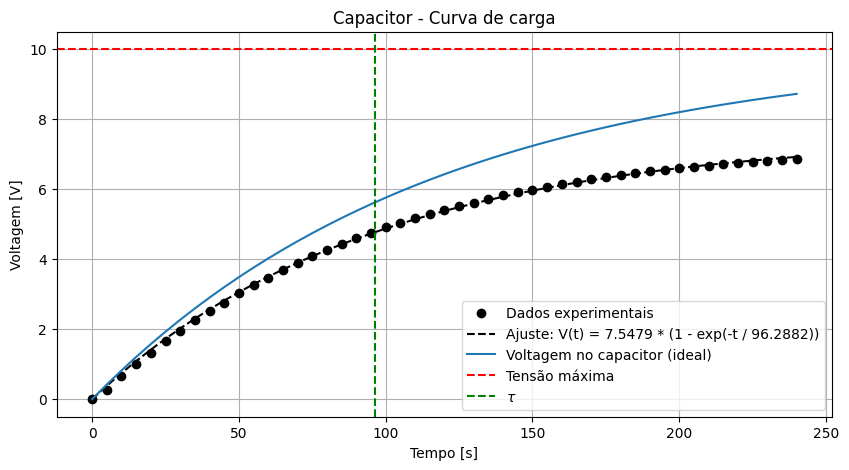

In [257]:
plt.figure(figsize=(10, 5))
plt.plot(t_exp, V_exp, 'ko', label='Dados experimentais')
plt.plot(x_fit, y_fit, 'k--', label='Ajuste: V(t) = {:.4f} * (1 - exp(-t / {:.4f}))'.format(A, B))
plt.plot(t_exp, Vcap_carga(t_exp, V, T), label='Voltagem no capacitor (ideal)')
plt.title('Capacitor - Curva de carga')
plt.xlabel('Tempo [s]')
plt.ylabel('Voltagem [V]')
plt.axhline(V, color='red', linestyle='--', label='Tensão máxima')
plt.axvline(B, color='green', linestyle='--', label=r'$\tau$')
plt.legend()
plt.grid()
plt.show()

---

Descarga

In [258]:
df = pd.read_excel('dados_capacitor_d.xlsx')

In [259]:
t_exp = df["T"] # Tempo em segundos
V_exp = df["V"] # Voltagem medida em volts

# Ajuste do modelo usando curve_fit
popt, pcov = curve_fit(Vcap_descarga, t_exp, V_exp, p0=[df["V"].iloc[0], T])

# Parâmetros ajustados
A, B = popt
print(f"Parâmetros ajustados: V0 = {A:.4f}, T = {B:.4f}")
print(f'Equação ajustada: V(t) = {A:.4f} * (1 - exp(-t / {B:.4f}))')

# Calcular o erro padrão dos parâmetros
perr = np.sqrt(np.diag(pcov))
print(f"Erro padrão dos parâmetros: V0 = {perr[0]:.4f}, T = {perr[1]:.4f}")

# Calcular R**2
slope, intercept, r_value, p_value, std_err = linregress(Vcap_carga(t_exp,*popt),V_exp)
print(f"R² = {r_value**2:.4f}")

# Gerar valores ajustados para o gráfico
x_fit = np.linspace(min(t_exp), max(t_exp), 100)
y_fit = Vcap_descarga(x_fit, A, B)

# Diferença quando t=tau
dif = Vcap_descarga(T, A, B) - Vcap_descarga(T, V, T)
print(f'Diferença quando t=tau: {abs(dif):.4f} V')

Parâmetros ajustados: V0 = 6.9343, T = 101.1822
Equação ajustada: V(t) = 6.9343 * (1 - exp(-t / 101.1822))
Erro padrão dos parâmetros: V0 = 0.0099, T = 0.2144
R² = 0.9999
Diferença quando t=tau: 1.4875 V


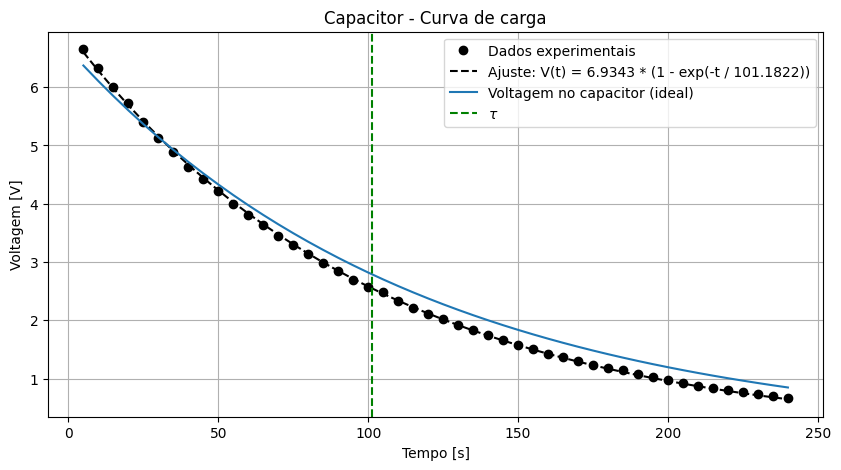

In [260]:
plt.figure(figsize=(10, 5))
plt.plot(t_exp, V_exp, 'ko', label='Dados experimentais')
plt.plot(x_fit, y_fit, 'k--', label='Ajuste: V(t) = {:.4f} * (1 - exp(-t / {:.4f}))'.format(A, B))
plt.plot(t_exp, Vcap_descarga(t_exp, df["V"].iloc[0], T), label='Voltagem no capacitor (ideal)')
plt.title('Capacitor - Curva de carga')
plt.xlabel('Tempo [s]')
plt.ylabel('Voltagem [V]')
plt.axvline(B, color='green', linestyle='--', label=r'$\tau$')
plt.legend()
plt.grid()
plt.show()